In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base = Path(r'C:\Users\hassa\OneDrive\سطح المكتب\IAU Hassan\4th Year FINALY\Image_Processing\LAB\Lab3')
image_path = './images/input.jpg'
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError('Put input.jpg inside the images folder')

gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print('Image loaded:', img.shape)

Image loaded: (256, 256, 3)


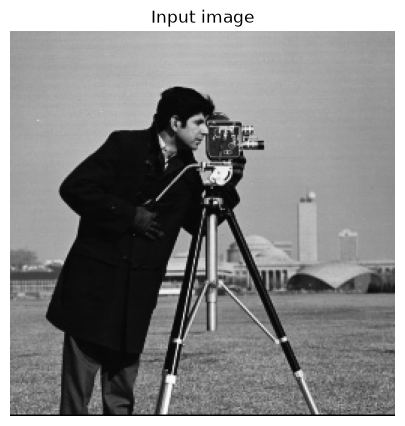

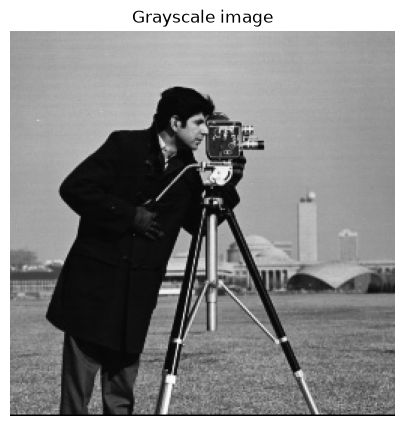

True

In [10]:
# Display the input image
plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Input image')
plt.axis('off')
plt.show()

# Grayscale image and save it
plt.figure(figsize=(6, 5))
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale image')
plt.axis('off')
plt.show()
cv2.imwrite('./images/output.jpg', gray_img)

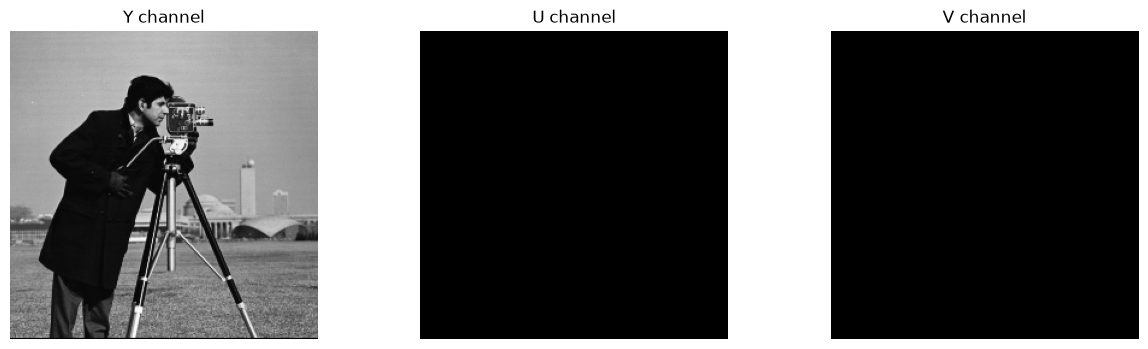

In [11]:
# YUV color space and its channels
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, channel, title in zip(ax, [yuv_img[:, :, 0], yuv_img[:, :, 1], yuv_img[:, :, 2]], ['Y channel', 'U channel', 'V channel']):
    a.imshow(channel, cmap='gray')
    a.set_title(title)
    a.axis('off')
plt.show()

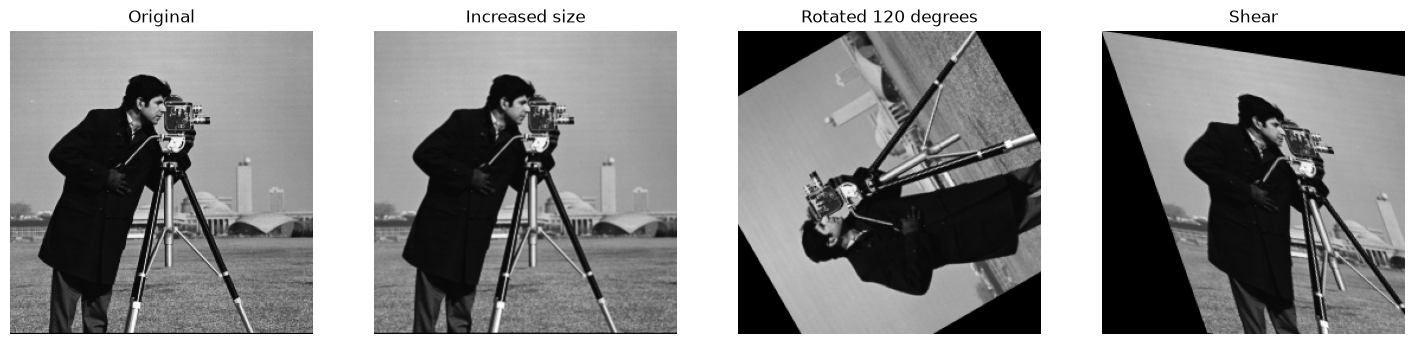

In [12]:
# Task 1: geometric transformations
height, width = gray_img.shape

increased = cv2.resize(gray_img, (width * 2, height * 2), interpolation=cv2.INTER_LINEAR)

center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated = cv2.warpAffine(gray_img, rotation_matrix, (width, height))

shear_matrix = np.float32([[1, 0.35, 0], [0.15, 1, 0]])
sheared = cv2.warpAffine(gray_img, shear_matrix, (width, height))

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for a, image, title in zip(ax, [gray_img, increased, rotated, sheared], ['Original', 'Increased size', 'Rotated 120 degrees', 'Shear']):
    a.imshow(image, cmap='gray')
    a.set_title(title)
    a.axis('off')
plt.show()

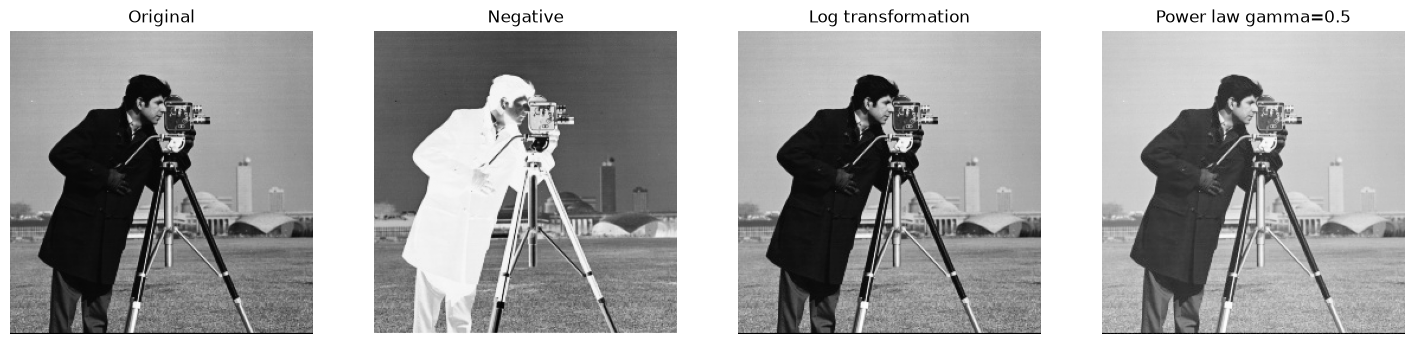

In [13]:
# Task 2: intensity transformations
image = gray_img.astype(np.float32) / 255.0

negative = 1.0 - image
c = 1.0 / np.log(1.0 + 1.0)
log_image = c * np.log(1.0 + image)
gamma = 0.5
power_image = np.power(image, gamma)

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for a, result, title in zip(ax, [image, negative, log_image, power_image], ['Original', 'Negative', 'Log transformation', 'Power law gamma=0.5']):
    a.imshow(result, cmap='gray', vmin=0, vmax=1)
    a.set_title(title)
    a.axis('off')
plt.show()